In [22]:
import json
import os
from PIL import Image
import matplotlib.pyplot as plt

### SQA test

In [23]:
# Config paths (adjust if needed)
sqa_test_folder = '../data/qa/SQA/SQA_test.json'
image_folder = '../data/qa/scannetv2/frames_square'

# Load the dataset
with open(sqa_test_folder, 'r') as f:
    sqa_data = json.load(f)

# Print dataset size
print(f"Total samples: {len(sqa_data)}")

Total samples: 3519


In [24]:
# View one sample
sample = sqa_data[0]
sample

{'answers': ['piano'],
 'object_ids': [],
 'object_names': [],
 'question': 'What instrument in front of me is ebony and ivory?',
 'situation': 'I am standing by the ottoman on my right facing a couple of toolboxes.',
 'question_id': 220602000002,
 'scene_id': 'scene0050_00',
 'position': [0.7110268899979686,
  -0.03219739162793617,
  0,
  0,
  0,
  -0.9995736030415032,
  -0.02919952230128897]}


Scene has 233 images total


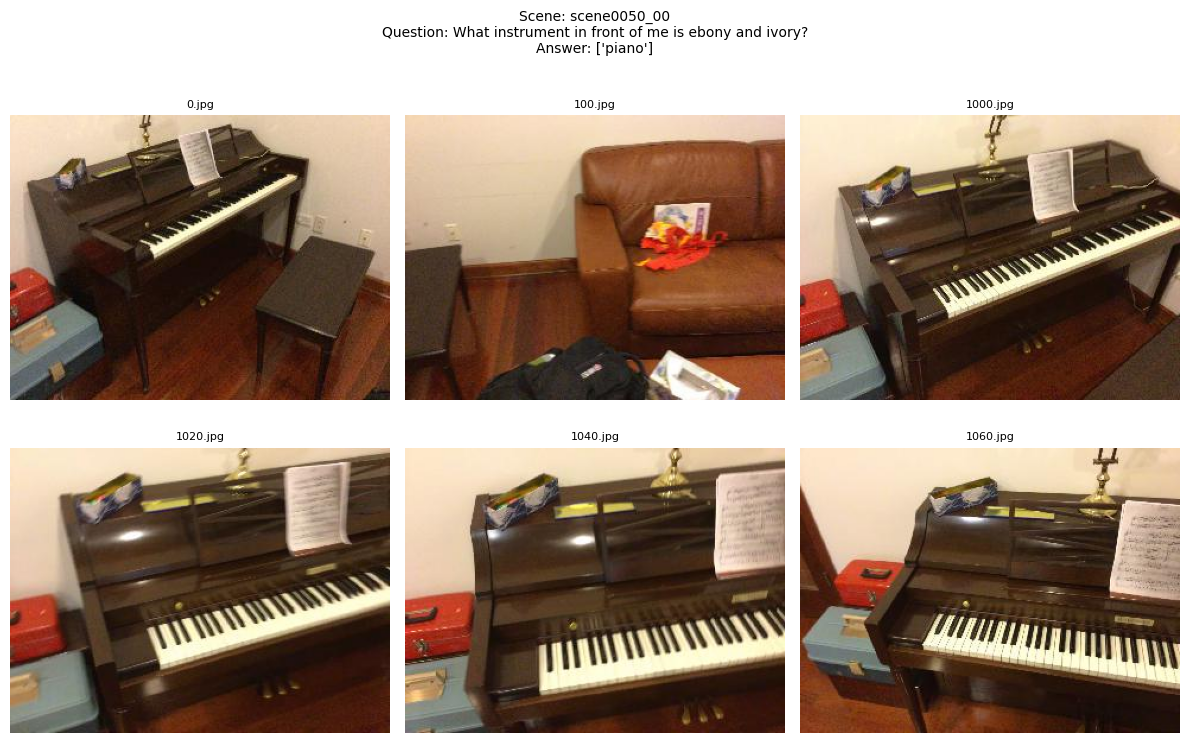

In [25]:
# Show a few images from this scene
scene_id = sample['scene_id']
color_folder = os.path.join(image_folder, scene_id, 'color')
image_files = sorted(os.listdir(color_folder))[:6]  # First 6 images

print(f"\nScene has {len(os.listdir(color_folder))} images total")

# Display images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle(f"Scene: {scene_id}\nQuestion: {sample['question']}\nAnswer: {sample['answers']}", fontsize=10)

for idx, (ax, img_file) in enumerate(zip(axes.flat, image_files)):
    img_path = os.path.join(color_folder, img_file)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_file, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

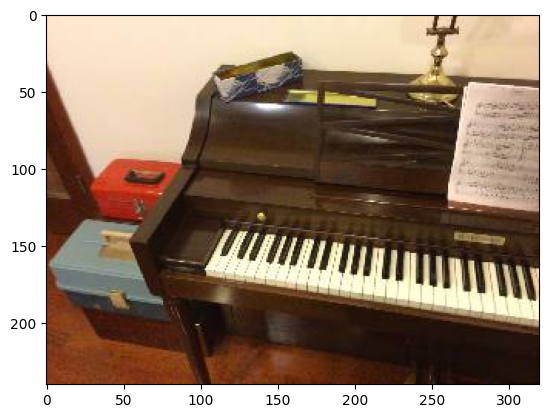

In [26]:
# write  code to plot just the first image
plt.imshow(Image.open(os.path.join(color_folder, image_files[5])))
plt.show()

### Set-of-Mark (SoM) Prompting

[Set-of-Mark](https://arxiv.org/abs/2310.11441) (Yang et al., 2023) is a visual prompting
technique that overlays numbered marks on automatically segmented image regions.
This helps vision-language models reference specific objects/areas by their mark ID.

**Pipeline:** Image → SAM (segment everything) → color-coded masks + numbered labels → SoM image

In [27]:
import numpy as np
import cv2
import colorsys
import torch
from PIL import Image, ImageDraw, ImageFont
from ultralytics.models.sam import SAM2Predictor


DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"


def make_sam2_predictor(model_name="sam2.1_l.pt", device=DEVICE):
    """Create a SAM2Predictor with only valid YOLO overrides."""
    return SAM2Predictor(overrides=dict(
        task="segment",
        mode="predict",
        imgsz=1024,
        model=model_name,
        device=device,
        verbose=False,
        save=False,
    ))


def generate_som_image(
    image_path,
    predictor,
    alpha=0.3,
    min_area_frac=0.0005,
    points_stride=16,
    crop_n_layers=1,
    conf_thres=0.86,
    stability_score_thresh=0.92,
):
    """Generate a Set-of-Mark (SoM) prompted image using SAM2.

    Segments the image with SAM2 in 'segment everything' mode using tuned
    parameters, then overlays colour-coded translucent masks with numbered
    labels at each segment centroid.

    Args:
        image_path: Path to the input image.
        predictor: A SAM2Predictor instance.
        alpha: Mask overlay opacity (0 = invisible, 1 = opaque).
        min_area_frac: Ignore masks smaller than this fraction of total pixels.
        points_stride: Sampling density — lower = denser grid = more segments.
        crop_n_layers: Extra crop layers for multi-scale mask generation.
        conf_thres: Predicted-IoU confidence threshold for mask quality.
        stability_score_thresh: Stability score threshold for mask filtering.

    Returns:
        som_img: np.ndarray (H, W, 3) — the marked image.
        n_marks: int — number of marks drawn.
    """
    img = np.array(Image.open(image_path).convert("RGB"))
    h, w = img.shape[:2]
    min_area = min_area_frac * h * w

    # SAM-specific generate kwargs are passed here (NOT in the constructor),
    # so they flow through __call__ → stream_inference → inference → generate
    # without hitting YOLO config validation.
    results = predictor(
        source=image_path,
        points_stride=points_stride,
        crop_n_layers=crop_n_layers,
        conf_thres=conf_thres,
        stability_score_thresh=stability_score_thresh,
    )

    if not results or results[0].masks is None:
        print("No masks detected.")
        return img, 0

    masks_raw = results[0].masks.data.cpu().numpy()
    scores = results[0].boxes.conf.cpu().numpy() if results[0].boxes is not None else None

    # Resize masks to image dimensions and filter by area
    processed = []
    for i, m in enumerate(masks_raw):
        if m.shape != (h, w):
            m = cv2.resize(m.astype(np.uint8), (w, h),
                           interpolation=cv2.INTER_NEAREST)
        mask_bool = m.astype(bool)
        area = mask_bool.sum()
        if area >= min_area:
            score = float(scores[i]) if scores is not None and i < len(scores) else 1.0
            processed.append((mask_bool, area, score))

    # Sort largest-first so small segments are painted on top
    processed.sort(key=lambda x: x[1], reverse=True)

    n = len(processed)
    if n == 0:
        print("All masks were below the minimum area threshold.")
        return img, 0

    # Distinct colours via golden-ratio hue spacing (avoids adjacent similarity)
    colors = []
    golden_ratio_inv = 0.618033988749895
    hue = 0.0
    for _ in range(n):
        r, g, b = colorsys.hsv_to_rgb(hue % 1.0, 0.75, 0.95)
        colors.append(np.array([int(r * 255), int(g * 255), int(b * 255)],
                               dtype=np.float64))
        hue += golden_ratio_inv

    # --- Paint translucent masks + contour outlines ---
    overlay = img.astype(np.float64)
    contour_layer = np.zeros_like(img)

    for (mask, _area, _score), color in zip(processed, colors):
        overlay[mask] = overlay[mask] * (1 - alpha) + color * alpha
        contours, _ = cv2.findContours(
            mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(contour_layer, contours, -1,
                         color.astype(int).tolist(), 2)

    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    contour_pixels = contour_layer.any(axis=2)
    overlay[contour_pixels] = contour_layer[contour_pixels]

    # --- Draw numbered labels ---
    som_pil = Image.fromarray(overlay)
    draw = ImageDraw.Draw(som_pil)

    font_size = max(12, min(h, w) // 45)
    try:
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", font_size)
    except OSError:
        font = ImageFont.load_default()

    for idx, ((mask, _area, _score), color) in enumerate(zip(processed, colors)):
        ys, xs = np.where(mask)
        if len(xs) == 0:
            continue
        cx, cy = int(xs.mean()), int(ys.mean())

        label = str(idx + 1)
        bbox = draw.textbbox((0, 0), label, font=font)
        tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
        pad = 4

        draw.rounded_rectangle(
            [cx - tw // 2 - pad, cy - th // 2 - pad,
             cx + tw // 2 + pad, cy + th // 2 + pad],
            radius=4, fill=(0, 0, 0, 210))
        draw.text((cx - tw // 2, cy - th // 2), label,
                  fill=(255, 255, 255), font=font)

    return np.array(som_pil), n

In [28]:
# SAM 2.1 Large — best accuracy, fast on V100 GPU
# Downloads sam2.1_l.pt automatically on first run (~430 MB)
print(f"Using device: {DEVICE}")

predictor = make_sam2_predictor("sam2.1_s.pt", device=DEVICE)

Using device: cuda:0


In [29]:
"""
som_image, n_marks = generate_som_image(
    test_image_path,
    predictor,
    points_stride=16,              # dense point grid (default 32)
    crop_n_layers=1,               # multi-scale crops for small objects
    conf_thres=0.86,               # predicted-IoU quality threshold
    stability_score_thresh=0.92,   # mask stability threshold
)
"""

'\nsom_image, n_marks = generate_som_image(\n    test_image_path,\n    predictor,\n    points_stride=16,              # dense point grid (default 32)\n    crop_n_layers=1,               # multi-scale crops for small objects\n    conf_thres=0.86,               # predicted-IoU quality threshold\n    stability_score_thresh=0.92,   # mask stability threshold\n)\n'

Ultralytics 8.4.30 🚀 Python-3.10.19 torch-2.11.0+cu126 CUDA:0 (NVIDIA H100 80GB HBM3, 81110MiB)


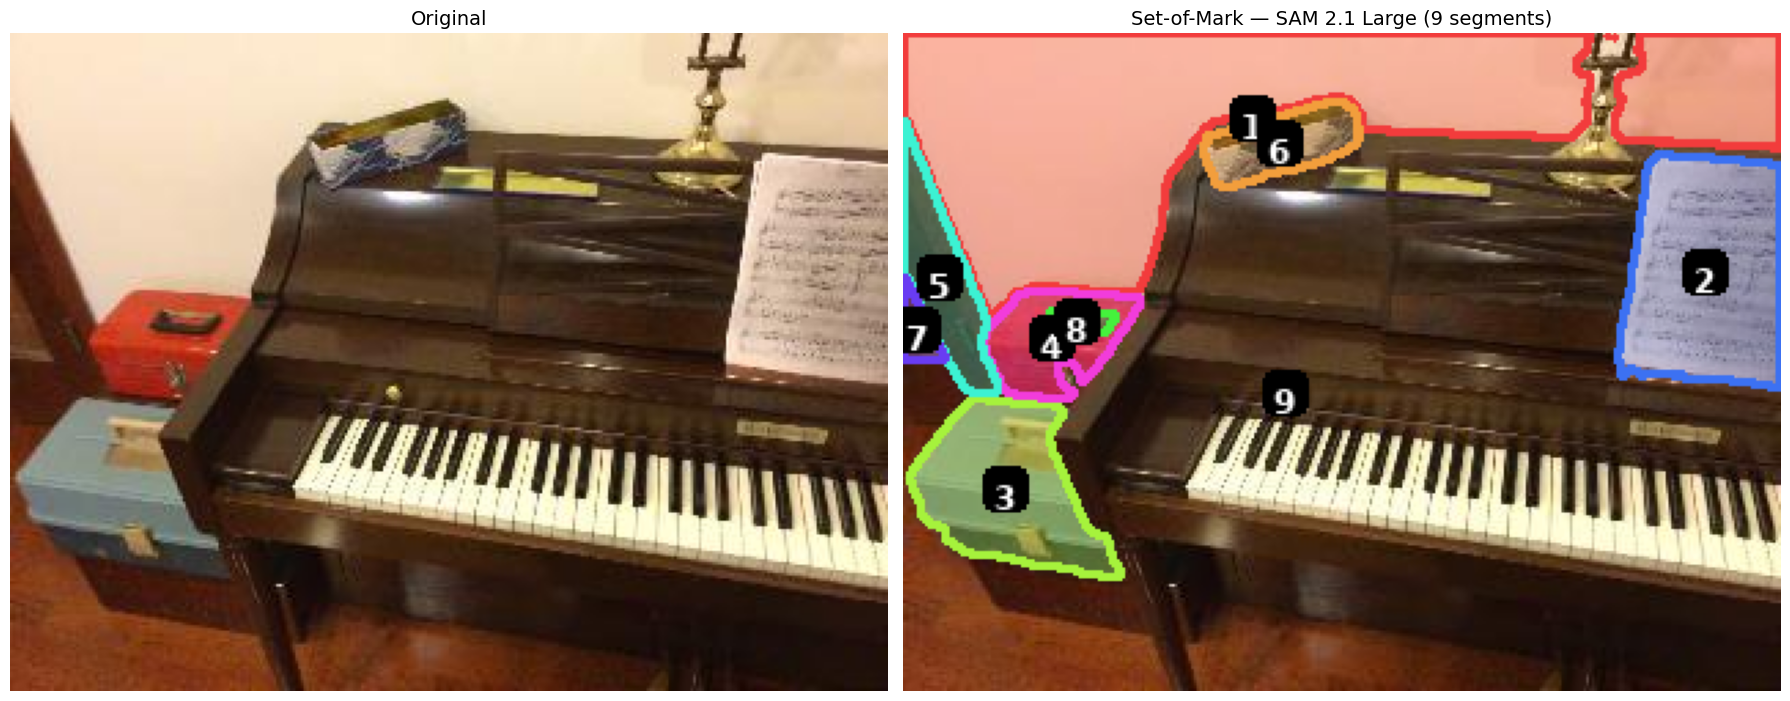

In [30]:
# Use the first image from the scene loaded earlier
test_image_path = os.path.join(color_folder, image_files[5])

som_image, n_marks = generate_som_image(
    test_image_path,
    predictor,
    points_stride=16,              # dense point grid (default 32)
    crop_n_layers=1,               # multi-scale crops for small objects
    conf_thres=0.86,               # predicted-IoU quality threshold
    stability_score_thresh=0.92,   # mask stability threshold
)

# Show original vs SoM side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(Image.open(test_image_path))
axes[0].set_title("Original", fontsize=14)
axes[0].axis("off")

axes[1].imshow(som_image)
axes[1].set_title(f"Set-of-Mark — SAM 2.1 Large ({n_marks} segments)", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Multi-View Object 3D Localization Pipeline

**Goal:** Detect objects by name in RGB views, then back-project through depth maps
to recover each object's 3D world coordinate.

**Pipeline:**
1. **Select keyframes** — pick N evenly-spaced views (avoid redundant nearby frames)
2. **Detect + Segment** — YOLO-World (open-vocab detection → names + boxes) → SAM2 (boxes → precise masks)
3. **Back-project** — for each mask, use depth + intrinsics + extrinsic pose to lift masked pixels to 3D world points; take the median as the object centroid
4. **Multi-view fusion** — cluster same-class 3D centroids across views with DBSCAN → one cluster = one physical object instance

In [31]:
import numpy as np
import os, glob, json
from PIL import Image
from sklearn.cluster import DBSCAN
from collections import defaultdict

# ─── Data loaders for ScanNet frames_square ──────────────────────────

def load_intrinsics(scene_dir):
    """Load 4x4 intrinsic matrix and scale to depth resolution (320x240).
    
    ScanNet intrinsic_depth.txt stores intrinsics at 640x480 native resolution.
    The depth images in frames_square are 320x240 → scale fx,fy,cx,cy by 0.5.
    """
    K = np.loadtxt(os.path.join(scene_dir, "intrinsic_depth.txt"))
    # Check if scaling is needed by comparing to actual depth image size
    sample_depth = sorted(glob.glob(os.path.join(scene_dir, "depth", "*.png")))[0]
    dh, dw = np.array(Image.open(sample_depth)).shape[:2]
    # If cx > dw, intrinsics are for a higher resolution → scale down
    if K[0, 2] > dw:
        scale = dw / (K[0, 2] * 2)   # e.g. 320 / (319*2) ≈ 0.5
        K[0, 0] *= scale  # fx
        K[1, 1] *= scale  # fy
        K[0, 2] *= scale  # cx
        K[1, 2] *= scale  # cy
    return K


def load_pose(scene_dir, frame_id):
    """Load 4x4 camera-to-world pose matrix for a frame."""
    pose = np.loadtxt(os.path.join(scene_dir, "pose", f"{frame_id}.txt"))
    if np.any(np.isinf(pose)) or np.any(np.isnan(pose)):
        return None
    return pose


def load_depth(scene_dir, frame_id):
    """Load depth map in meters (ScanNet stores uint16 millimeters)."""
    path = os.path.join(scene_dir, "depth", f"{frame_id}.png")
    depth = np.array(Image.open(path)).astype(np.float32) / 1000.0
    return depth


def get_frame_ids(scene_dir):
    """Get sorted list of all available frame IDs."""
    files = glob.glob(os.path.join(scene_dir, "color", "*.jpg"))
    ids = sorted([int(os.path.splitext(os.path.basename(f))[0]) for f in files])
    return ids


def select_keyframes(frame_ids, n_keyframes=20):
    """Evenly sample n keyframes from all available frames."""
    if len(frame_ids) <= n_keyframes:
        return frame_ids
    indices = np.linspace(0, len(frame_ids) - 1, n_keyframes, dtype=int)
    return [frame_ids[i] for i in indices]


# ─── 2D mask → 3D world coordinates ──────────────────────────────────

def backproject_mask(mask, depth, K, cam2world, max_depth=5.0, subsample=500):
    """Back-project pixels within a binary mask to 3D world coordinates.
    
    Args:
        mask: (H, W) boolean mask
        depth: (H, W) float depth in meters
        K: 4x4 intrinsic matrix
        cam2world: 4x4 extrinsic pose (camera → world)
        max_depth: ignore depth values above this (noisy)
        subsample: max points to use (for speed)
    
    Returns:
        points_world: (N, 3) array of 3D world points, or None if too few valid
    """
    fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]
    
    vs, us = np.where(mask)
    depths = depth[vs, us]

    valid = (depths > 0.01) & (depths < max_depth)
    us, vs, depths = us[valid], vs[valid], depths[valid]

    if len(us) < 10:
        return None

    if len(us) > subsample:
        idx = np.random.choice(len(us), subsample, replace=False)
        us, vs, depths = us[idx], vs[idx], depths[idx]

    # Pixel → camera coordinates
    X_cam = (us - cx) * depths / fx
    Y_cam = (vs - cy) * depths / fy
    Z_cam = depths

    pts_cam = np.stack([X_cam, Y_cam, Z_cam, np.ones_like(Z_cam)], axis=1)  # (N, 4)

    pts_world = (cam2world @ pts_cam.T).T[:, :3]  # (N, 3)
    return pts_world


def mask_to_3d_centroid(mask, depth, K, cam2world):
    """Get the median 3D world coordinate for a mask (robust to outliers)."""
    pts = backproject_mask(mask, depth, K, cam2world)
    if pts is None:
        return None
    return np.median(pts, axis=0)

print("Utilities loaded.")

Utilities loaded.


In [32]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from ultralytics import YOLOWorld
import cv2

# ─── Detector setup ──────────────────────────────────────────────────

INDOOR_CLASSES = [
    "chair", "table", "sofa", "couch", "desk", "bed", "nightstand",
    "door", "window", "curtain", "blinds",
    "lamp", "light", "ceiling light",
    "monitor", "tv", "screen", "keyboard", "laptop",
    "shelf", "bookshelf", "cabinet", "drawer", "wardrobe", "closet",
    "refrigerator", "microwave", "oven", "sink", "toilet", "bathtub", "shower",
    "mirror", "picture", "painting", "clock", "poster",
    "plant", "vase", "flower",
    "pillow", "blanket", "towel", "rug", "carpet", "mat",
    "bottle", "cup", "mug", "bowl", "plate",
    "bag", "backpack", "box", "bin", "trash can",
    "book", "paper", "phone", "remote",
    "fan", "heater", "radiator",
    "counter", "stool", "bench",
]

yolo_world = YOLOWorld("yolov8x-worldv2.pt")
yolo_world.set_classes(INDOOR_CLASSES)

print(f"YOLO-World loaded with {len(INDOOR_CLASSES)} classes")
print(f"SAM2 predictor already loaded: {type(predictor)}")


# ─── Per-frame: detect + segment + back-project ──────────────────────

def detect_and_locate_3d(
    scene_dir,
    frame_id,
    yolo_model,
    sam_predictor,
    K,
    det_conf=0.15,
    min_mask_area=200,
):
    """Run full pipeline on a single frame: detect → segment → back-project.
    
    Returns list of dicts: [{name, confidence, centroid_3d, bbox, frame_id}, ...]
    """
    color_path = os.path.join(scene_dir, "color", f"{frame_id}.jpg")
    cam2world = load_pose(scene_dir, frame_id)
    if cam2world is None:
        return []

    depth = load_depth(scene_dir, frame_id)

    # Step 1: YOLO-World detection
    det_results = yolo_model(color_path, conf=det_conf, verbose=False)
    boxes = det_results[0].boxes
    if boxes is None or len(boxes) == 0:
        return []

    bboxes_np = boxes.xyxy.cpu().numpy()
    class_ids = boxes.cls.cpu().numpy().astype(int)
    confs = boxes.conf.cpu().numpy()
    names = [yolo_model.names[c] for c in class_ids]

    # Step 2: SAM2 segmentation from detected bounding boxes
    sam_results = sam_predictor(source=color_path, bboxes=bboxes_np)
    if not sam_results or sam_results[0].masks is None:
        return []

    masks_raw = sam_results[0].masks.data.cpu().numpy()
    h, w = depth.shape

    detections = []
    for i, (name, conf) in enumerate(zip(names, confs)):
        if i >= len(masks_raw):
            break

        mask = masks_raw[i]
        if mask.shape != (h, w):
            mask = cv2.resize(mask.astype(np.uint8), (w, h),
                              interpolation=cv2.INTER_NEAREST)
        mask = mask.astype(bool)

        if mask.sum() < min_mask_area:
            continue

        centroid = mask_to_3d_centroid(mask, depth, K, cam2world)
        if centroid is None:
            continue

        detections.append({
            "name": name,
            "confidence": float(conf),
            "centroid_3d": centroid,
            "bbox": bboxes_np[i].tolist(),
            "frame_id": frame_id,
        })

    return detections

print("Detection pipeline ready.")

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 312MiB/s]


YOLO-World loaded with 66 classes
SAM2 predictor already loaded: <class 'ultralytics.models.sam.predict.SAM2Predictor'>
Detection pipeline ready.


In [33]:
# ─── Multi-view fusion: cluster detections into object instances ──────

def fuse_multiview_detections(all_detections, eps=0.3, min_samples=2):
    """Cluster per-frame 3D detections into unique object instances.
    
    Groups detections by class name, then uses DBSCAN to merge
    nearby centroids from different views into a single instance.
    
    Args:
        all_detections: flat list of detection dicts from detect_and_locate_3d
        eps: DBSCAN radius in meters (0.3m works well for indoor objects)
        min_samples: minimum views to confirm an object exists
    
    Returns:
        objects: list of dicts [{name, position_3d, n_views, avg_confidence}, ...]
    """
    by_class = defaultdict(list)
    for det in all_detections:
        by_class[det["name"]].append(det)

    objects = []
    for name, dets in by_class.items():
        centroids = np.array([d["centroid_3d"] for d in dets])
        confs = np.array([d["confidence"] for d in dets])

        if len(centroids) == 1:
            # Single detection — keep it but flag low confidence
            objects.append({
                "name": name,
                "position_3d": centroids[0],
                "n_views": 1,
                "avg_confidence": float(confs[0]),
            })
            continue

        clustering = DBSCAN(eps=eps, min_samples=min(min_samples, len(centroids))).fit(centroids)
        labels = clustering.labels_

        for label in set(labels):
            if label == -1:
                continue
            member_mask = labels == label
            cluster_pts = centroids[member_mask]
            cluster_confs = confs[member_mask]
            objects.append({
                "name": name,
                "position_3d": cluster_pts.mean(axis=0),
                "n_views": int(member_mask.sum()),
                "avg_confidence": float(cluster_confs.mean()),
            })

    objects.sort(key=lambda o: o["avg_confidence"], reverse=True)
    return objects


def run_full_pipeline(scene_dir, yolo_model, sam_predictor, n_keyframes=20):
    """End-to-end: select keyframes → detect → fuse → return 3D objects."""
    K = load_intrinsics(scene_dir)
    frame_ids = get_frame_ids(scene_dir)
    keyframes = select_keyframes(frame_ids, n_keyframes)

    print(f"Processing {len(keyframes)} keyframes from {len(frame_ids)} total frames...")

    all_detections = []
    for i, fid in enumerate(keyframes):
        dets = detect_and_locate_3d(scene_dir, fid, yolo_model, sam_predictor, K)
        all_detections.extend(dets)
        if (i + 1) % 5 == 0:
            print(f"  [{i+1}/{len(keyframes)}] {len(all_detections)} detections so far")

    print(f"Total raw detections: {len(all_detections)}")

    objects = fuse_multiview_detections(all_detections)
    print(f"Fused into {len(objects)} unique object instances")
    return objects, all_detections

print("Fusion pipeline ready.")

Fusion pipeline ready.


In [34]:
# ─── Run on a scene ──────────────────────────────────────────────────

scene_dir = os.path.join(image_folder, scene_id)
print(f"Scene: {scene_id}  →  {scene_dir}")

objects_3d, raw_detections = run_full_pipeline(
    scene_dir, yolo_world, predictor, n_keyframes=20
)

# Pretty-print results
print(f"\n{'='*60}")
print(f"  3D Object Map for {scene_id}")
print(f"{'='*60}")
for i, obj in enumerate(objects_3d):
    pos = obj["position_3d"]
    print(f"  {i+1:2d}. {obj['name']:20s}  "
          f"xyz=({pos[0]:+6.2f}, {pos[1]:+6.2f}, {pos[2]:+6.2f})  "
          f"views={obj['n_views']}  conf={obj['avg_confidence']:.2f}")

Scene: scene0050_00  →  ../data/qa/scannetv2/frames_square/scene0050_00
Processing 20 keyframes from 233 total frames...
  [5/20] 38 detections so far
  [10/20] 74 detections so far
  [15/20] 106 detections so far
  [20/20] 141 detections so far
Total raw detections: 141
Fused into 29 unique object instances

  3D Object Map for scene0050_00
   1. bottle                xyz=( +3.18,  +2.39,  +1.13)  views=2  conf=0.59
   2. chair                 xyz=( +2.81,  +1.93,  +0.78)  views=4  conf=0.53
   3. bottle                xyz=( +3.30,  +2.81,  +1.12)  views=2  conf=0.50
   4. bag                   xyz=( +4.48,  +1.95,  +0.79)  views=3  conf=0.48
   5. carpet                xyz=( +2.79,  +1.89,  +0.75)  views=2  conf=0.47
   6. box                   xyz=( +6.45,  +2.59,  +0.67)  views=2  conf=0.41
   7. carpet                xyz=( +3.70,  +2.91,  +0.67)  views=2  conf=0.38
   8. mirror                xyz=( +6.29,  +3.10,  +0.72)  views=1  conf=0.38
   9. towel                 xyz=( +3.74,

/tmp/ipykernel_102095/148387119.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_names))


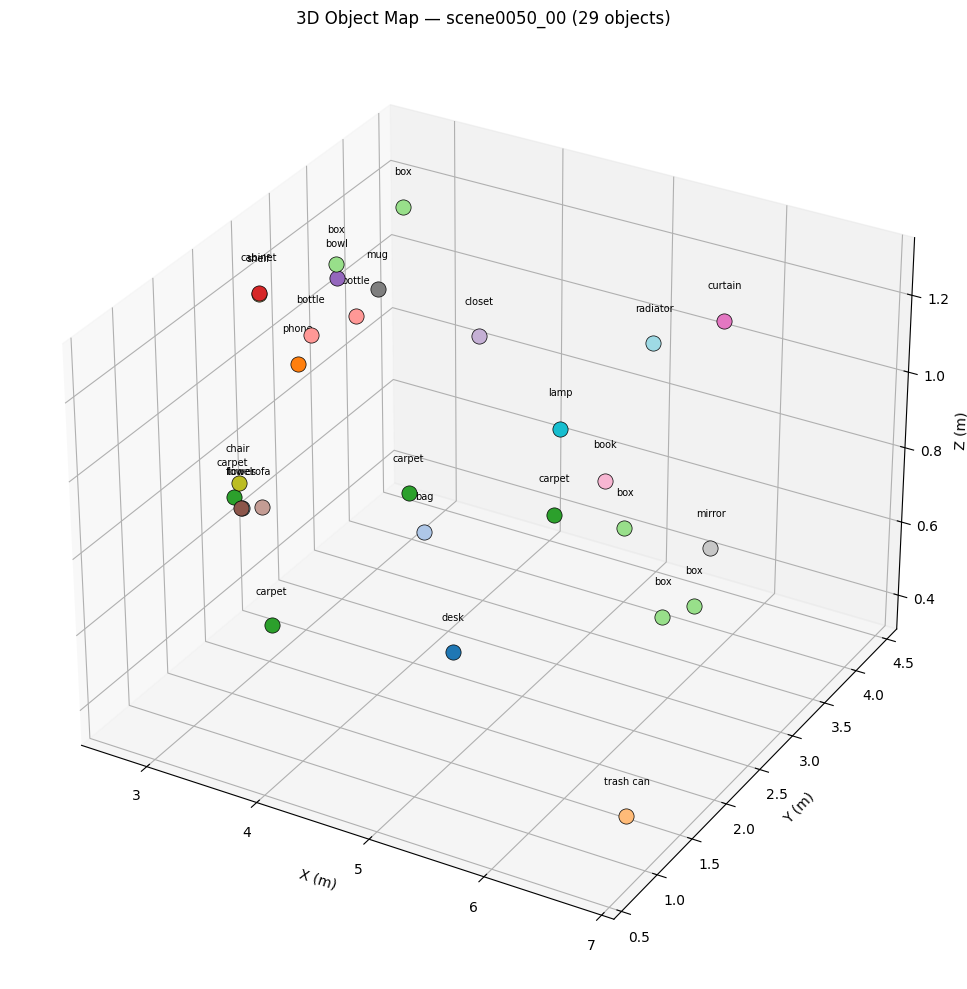


Name                       X       Y       Z Views  Conf
-------------------------------------------------------
bottle                 +3.18   +2.39   +1.13     2  0.59
chair                  +2.81   +1.93   +0.78     4  0.53
bottle                 +3.30   +2.81   +1.12     2  0.50
bag                    +4.48   +1.95   +0.79     3  0.48
carpet                 +2.79   +1.89   +0.75     2  0.47
box                    +6.45   +2.59   +0.67     2  0.41
carpet                 +3.70   +2.91   +0.67     2  0.38
mirror                 +6.29   +3.10   +0.72     1  0.38
towel                  +3.74   +0.67   +1.00     1  0.38
book                   +6.36   +1.43   +1.17     2  0.36
trash can              +6.80   +1.05   +0.42     1  0.34
carpet                 +2.92   +2.15   +0.37     3  0.30
box                    +6.41   +2.19   +0.70     2  0.29
box                    +6.22   +1.94   +0.96     4  0.28
lamp                   +5.99   +1.41   +1.27     2  0.28
cabinet                +2.70   

In [35]:
# ─── 3D scatter plot of detected objects ─────────────────────────────

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

unique_names = list({o["name"] for o in objects_3d})
cmap = plt.cm.get_cmap("tab20", len(unique_names))
name_to_color = {n: cmap(i) for i, n in enumerate(unique_names)}

for obj in objects_3d:
    pos = obj["position_3d"]
    color = name_to_color[obj["name"]]
    ax.scatter(*pos, c=[color], s=120, edgecolors='k', linewidths=0.5, zorder=5)
    ax.text(pos[0], pos[1], pos[2] + 0.08, obj["name"],
            fontsize=7, ha='center', va='bottom')

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_title(f"3D Object Map — {scene_id} ({len(objects_3d)} objects)")
plt.tight_layout()
plt.show()


# ─── Table view ──────────────────────────────────────────────────────
print(f"\n{'Name':20s} {'X':>7s} {'Y':>7s} {'Z':>7s} {'Views':>5s} {'Conf':>5s}")
print("-" * 55)
for obj in objects_3d:
    p = obj["position_3d"]
    print(f"{obj['name']:20s} {p[0]:+7.2f} {p[1]:+7.2f} {p[2]:+7.2f} "
          f"{obj['n_views']:5d} {obj['avg_confidence']:5.2f}")